<a href="https://colab.research.google.com/github/greeshmapj/AI-course-notes/blob/main/Sec12_encoding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# missing, duplica, outliers, skewness, encoding , scaling ...( dtatype, date, column, ....)

<Axes: >

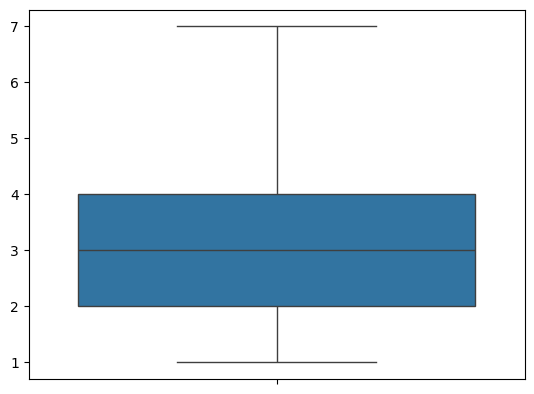

In [ ]:
import pandas as pd
age=pd.Series([1,2,3,4,7])
sns.boxplot(age)


In [ ]:
age.skew()

np.float64(1.0326585393989953)

<Axes: >

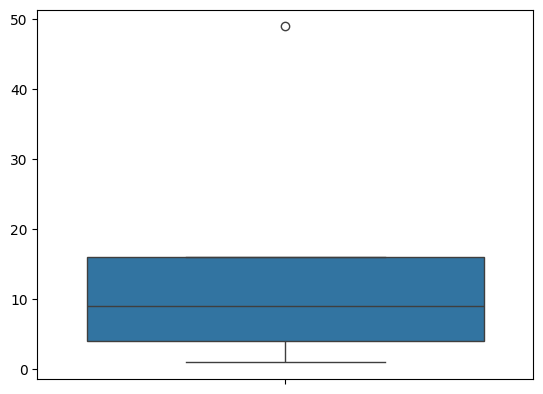

In [ ]:
age=pd.Series([1,2,3,4,7]) #np.float64(1.0326585393989953)

age=pd.Series([1,4,9,16,49]) #0.69958922764032
sns.boxplot(age)

In [ ]:
age.skew()

np.float64(1.7891941740668076)

# **🔐 Encoding **
## **📌 What is Encoding?**

Encoding is the process of converting categorical (textual) data into numerical form so that machine learning models can understand and process it.

Most ML algorithms work only with numbers, not text.

# 📊 Types of Data That Need Encoding

1. Nominal data → No order

Example: Color = Red, Blue, Green

2. Ordinal data → Has order

Example: Size = Small < Medium < Large


# **What is Label Encoding?**

Label Encoding is a categorical encoding technique where each unique category is converted into a numeric label (integer).

📌 Example:

Color → Encoded

Red   → 0

Blue  → 1

Green → 2

In [ ]:
import pandas as pd
data=pd.read_excel('/content/cat data (1).xlsx')

In [ ]:
data.head()

,ID,Name,Email,Gender,Education_Level,Product_Category,City,Purchased
0,1,Alice,alice@gmail.com,Female,UG,Electronics,Kochi,1
1,2,Robert,robert@gmail.com,Male,PG,Clothing,TVM,0
2,3,Emma,emma@gmail.com,Female,PhD,Furniture,Kochi,1
3,4,James,james@gmail.com,Male,UG,Grocery,Calicut,0
4,5,Sophia,sophia@gmail.com,Female,PG,Electronics,Kochi,1


# lets see the data

| Column               | Type               | Categorical Type | Cardinality           | Notes                                                      |
| -------------------- | ------------------ | ---------------- | --------------------- | ---------------------------------------------------------- |
| **ID**               | Numerical          | Identifier       | 25 (unique)           | Unique identifier, no predictive value                     |
| **Name**             | Text               | Identifier       | 25 (unique)           | Each name is unique → do not encode                        |
| **Email**            | Text               | Identifier       | 25 (unique)           | Unique → cannot encode                                     |
| **Gender**           | Categorical        | Nominal (binary) | 2                     | Low cardinality, only Male/Female                          |
| **Education_Level**  | Categorical        | Ordinal          | 3                     | UG < PG < PhD → order matters                              |
| **Product_Category** | Categorical        | Nominal          | 4                     | Medium cardinality → separate binary columns               |
| **City**             | Categorical        | Nominal          | 7+ (high cardinality) | High cardinality, use target mean to reduce dimensionality |
| **Purchased**        | Numerical / Binary | Target           | 2                     | Already numeric → target variable, do not encode           |


# 📊 Encoding Techniques in Data Science

Data preprocessing often requires converting categorical variables into numeric form so that machine learning models can understand them. Below are the main encoding techniques used in practice.

---

## 1️⃣ Label Encoding
- **What:** Converts categories into numbers.  
- **Example:**  
Male → 1

Female → 0

- **Best for:** Binary or low-cardinality features; tree-based models.  
- **Column Example:** Gender  
- **Notes:** Introduces numeric values but may imply order. Suitable for models that do not assume linear relationships (e.g., Decision Trees, Random Forests).

---

## 2️⃣ Ordinal Encoding
- **What:** Converts categories with **natural order** into numbers.  
- **Example:**  
UG → 0

PG → 1

PhD → 2

- **Best for:** Ordinal features where **order matters**.  
- **Column Example:** Education_Level  
- **Notes:** Numbers represent rank/order. Avoid for nominal data.

---

## 3️⃣ One-Hot Encoding (MOST IMPORTANT)
- **What:** Creates **binary columns** for each category.  
- **Example:**  
Electronics → [1,0,0,0]

Clothing → [0,1,0,0]

Furniture → [0,0,1,0]

Grocery → [0,0,0,1]


- **Best for:** Nominal features with **low to medium cardinality**.  
- **Column Example:** Product_Category  
- **Notes:** Avoid creating too many columns for high-cardinality data (may cause memory issues). Works well with linear models.

---

## 4️⃣ Target Encoding (Advanced)
- **What:** Replaces categories with the **mean value of the target variable**.  
- **Example:**  
City:

Kochi → 0.67

TVM → 0.00

Calicut → 0.00

- **Best for:** Nominal features with **high cardinality**.  
- **Column Example:** City  
- **Notes:** Can lead to **data leakage** if not used carefully. Typically applied with cross-validation.

---

## 💡 Quick Tips
- **Ordinal → Label Encoding** (order matters)  
- **Nominal → One-Hot Encoding** (no order)  
- **High-cardinality → Target Encoding**  
- Tree-based models tolerate Label Encoding; linear models often need One-Hot Encoding.  
- Always consider **cardinality** and **model type** when choosing encoding.

---

## ✅ Summary Table

| Technique           | Example                          | Best Use                          | Column Example       |
|--------------------|---------------------------------|----------------------------------|--------------------|
| Label Encoding      | Male → 1, Female → 0            | Binary/low-cardinality features  | Gender             |
| Ordinal Encoding    | UG → 0, PG → 1, PhD → 2        | Ordinal features (order matters) | Education_Level    |
| One-Hot Encoding    | Electronics → [1,0,0,0]        | Nominal features, low-medium cardinality | Product_Category   |
| Target Encoding     | Kochi → 0.67, TVM → 0.00       | Nominal features, high cardinality | City               |



In [ ]:
# Import required libraries
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

In [ ]:
# -------------------------
# 2️⃣ Encode Gender (Label Encoding)
# -------------------------
le = LabelEncoder()
data['Gender'] =le.fit_transform(data["Gender"])  # Female=0, Male=1
# Note: Label encoding is suitable for binary or low-cardinality columns

data

,ID,Name,Email,Gender,Education_Level,Product_Category,City,Purchased
0,1,Alice,alice@gmail.com,0,UG,Electronics,Kochi,1
1,2,Robert,robert@gmail.com,1,PG,Clothing,TVM,0
2,3,Emma,emma@gmail.com,0,PhD,Furniture,Kochi,1
3,4,James,james@gmail.com,1,UG,Grocery,Calicut,0
4,5,Sophia,sophia@gmail.com,0,PG,Electronics,Kochi,1
5,6,Daniel,daniel@gmail.com,1,UG,Clothing,Trivandrum,0
6,7,Olivia,olivia@gmail.com,0,PG,Grocery,Kochi,1
7,8,Michael,michael@gmail.com,1,PhD,Furniture,Bangalore,0
8,9,Isabella,isabella@gmail.com,0,UG,Electronics,Chennai,1
9,10,William,william@gmail.com,1,PG,Clothing,Kochi,1


In [ ]:
le.inverse_transform([1]) #le.fit_transform(data['Gender'])

array(['Male'], dtype=object)

In [ ]:
# -------------------------
# 3️⃣ Encode Education_Level (Ordinal Encoding)
# -------------------------
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[['UG','PG','PhD']]) #in order asc
data['Education_Level'] = oe.fit_transform(data[['Education_Level']])
# Note: Ordinal encoding preserves order (UG<PG<PhD)

data

,ID,Name,Email,Gender,Education_Level,Product_Category,City,Purchased
0,1,Alice,alice@gmail.com,0,0.0,Electronics,Kochi,1
1,2,Robert,robert@gmail.com,1,1.0,Clothing,TVM,0
2,3,Emma,emma@gmail.com,0,2.0,Furniture,Kochi,1
3,4,James,james@gmail.com,1,0.0,Grocery,Calicut,0
4,5,Sophia,sophia@gmail.com,0,1.0,Electronics,Kochi,1
5,6,Daniel,daniel@gmail.com,1,0.0,Clothing,Trivandrum,0
6,7,Olivia,olivia@gmail.com,0,1.0,Grocery,Kochi,1
7,8,Michael,michael@gmail.com,1,2.0,Furniture,Bangalore,0
8,9,Isabella,isabella@gmail.com,0,0.0,Electronics,Chennai,1
9,10,William,william@gmail.com,1,1.0,Clothing,Kochi,1


In [ ]:
# -------------------------
# 3️⃣ Encode Product_Category (One-Hot Encoding)
# -------------------------
import pandas as pd
data = pd.get_dummies(data, columns=['Product_Category'],dtype=int,drop_first = True)
# Note: One-Hot encoding is used for nominal features with medium cardinality
data

,ID,Name,Email,Gender,Education_Level,City,Purchased,Product_Category_Electronics,Product_Category_Furniture,Product_Category_Grocery
0,1,Alice,alice@gmail.com,0,0.0,Kochi,1,1,0,0
1,2,Robert,robert@gmail.com,1,1.0,TVM,0,0,0,0
2,3,Emma,emma@gmail.com,0,2.0,Kochi,1,0,1,0
3,4,James,james@gmail.com,1,0.0,Calicut,0,0,0,1
4,5,Sophia,sophia@gmail.com,0,1.0,Kochi,1,1,0,0
5,6,Daniel,daniel@gmail.com,1,0.0,Trivandrum,0,0,0,0
6,7,Olivia,olivia@gmail.com,0,1.0,Kochi,1,0,0,1
7,8,Michael,michael@gmail.com,1,2.0,Bangalore,0,0,1,0
8,9,Isabella,isabella@gmail.com,0,0.0,Chennai,1,1,0,0
9,10,William,william@gmail.com,1,1.0,Kochi,1,0,0,0


In [ ]:
(1+0+0)/3

0.3333333333333333

In [ ]:
data["City"].value_counts()

,count
City,
Kochi,10
TVM,3
Bangalore,3
Chennai,3
Calicut,2
Trivandrum,2
Mumbai,2


In [ ]:
# -------------------------
# 4️⃣ Encode City (Target Encoding using Purchased)
# -------------------------
# Calculate mean Purchased per City
city_target_mean = data.groupby('City')['Purchased'].mean() #.333333
# Map City to mean value
data['City'] = data['City'].map(city_target_mean)
# Note: Target encoding is suitable for high-cardinality nominal features
# ⚠️ Be careful with data leakage in real-world projects

# -------------------------
#  Display Encoded Dataset
# -------------------------
data

,ID,Name,Email,Gender,Education_Level,City,Purchased,Product_Category_Electronics,Product_Category_Furniture,Product_Category_Grocery
0,1,Alice,alice@gmail.com,0,0.0,1.000000,1,1,0,0
1,2,Robert,robert@gmail.com,1,1.0,0.000000,0,0,0,0
2,3,Emma,emma@gmail.com,0,2.0,1.000000,1,0,1,0
3,4,James,james@gmail.com,1,0.0,0.000000,0,0,0,1
4,5,Sophia,sophia@gmail.com,0,1.0,1.000000,1,1,0,0
5,6,Daniel,daniel@gmail.com,1,0.0,0.000000,0,0,0,0
6,7,Olivia,olivia@gmail.com,0,1.0,1.000000,1,0,0,1
7,8,Michael,michael@gmail.com,1,2.0,0.333333,0,0,1,0
8,9,Isabella,isabella@gmail.com,0,0.0,0.333333,1,1,0,0
9,10,William,william@gmail.com,1,1.0,1.000000,1,0,0,0


In [ ]:
data[data["City"]=="Calicut"] ["Purchased"].mean()#groupby

np.float64(0.0)

# **Scaling & Normalization – Key Technique**

Why We Do Scaling / Normalization

1️⃣ Machine Learning Models Require Comparable Features

Most ML algorithms work on mathematical calculations (distances, gradients, etc.)

If one feature has a large range and another has a small range, the model will give more importance to the larger feature.

Example:

Size of house: 500–5000 sq.ft

Bedrooms: 1–6

Without scaling, Size dominates the model → Bedrooms almost ignored

2️⃣ Speeds Up Model Convergence

Neural networks and gradient-based algorithms converge faster when input features are in a similar scale

Prevents unstable updates in weights

3️⃣ Improves Model Accuracy

Distance-based algorithms (KNN, K-Means, SVM) rely on Euclidean distance

Scaling ensures all features contribute equally to distance calculation

| Feature      | Original Range | After Min-Max Scaling (0-1) |
| ------------ | -------------- | --------------------------- |
| Size (sq.ft) | 500–5000       | 0.0–1.0                     |
| Bedrooms     | 1–6            | 0.0–1.0                     |


In [ ]:
import seaborn as sns
import pandas as pd

# Load the tips dataset
tips = sns.load_dataset('tips')

# Select numeric columns for scaling
tips_numeric = tips[['total_bill', 'tip', 'size']]

print("Before scaling:\n")
tips_numeric.describe()


Before scaling:



,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


<Axes: xlabel='total_bill', ylabel='Density'>

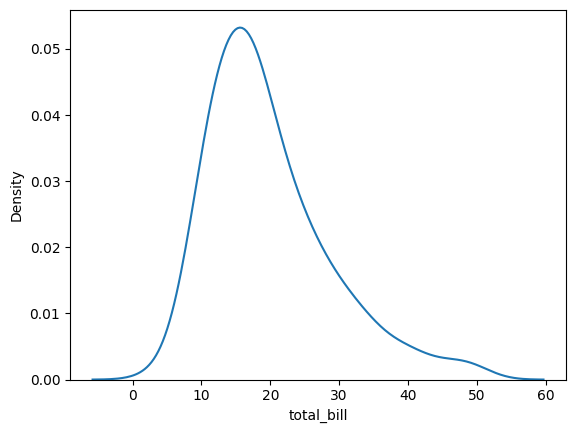

In [ ]:
sns.kdeplot(tips_numeric["total_bill"]) #displot, dist, hist

🔹 2. Apply Min‑Max Scaling (0–1)

Min‑Max scaling rescales values to between 0 and 1:

In [ ]:
from sklearn.preprocessing import MinMaxScaler

minmax = MinMaxScaler()
tips_minmax = pd.DataFrame(minmax.fit_transform(tips_numeric))
print("After Min‑Max Scaling:\n")
tips_minmax.describe()


After Min‑Max Scaling:



,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,0.350145,0.222031,0.313934
std,0.186477,0.153738,0.190220
min,0.000000,0.000000,0.000000
25%,0.215281,0.111111,0.200000
50%,0.308442,0.211111,0.200000
75%,0.441087,0.284722,0.400000
max,1.000000,1.000000,1.000000


In [ ]:
babkdeposit =[10000, 50000, 10000000]

<Axes: xlabel='total_bill', ylabel='Density'>

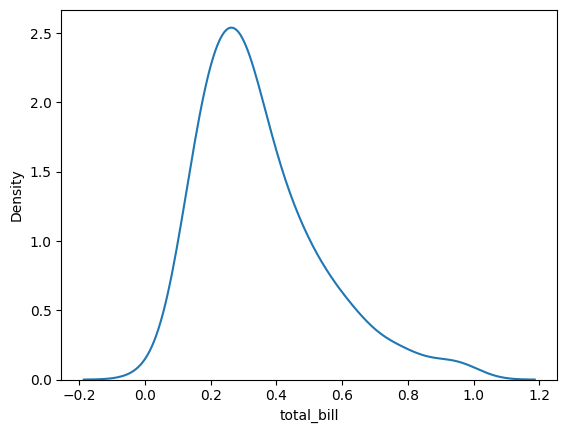

In [ ]:
sns.kdeplot(tips_minmax["total_bill"])

3. Apply Standardization (Z‑score)

Standardization scales data to mean 0 and standard deviation 1:

In [ ]:
from sklearn.preprocessing import StandardScaler #mean ,

std = StandardScaler()
tips_standard = pd.DataFrame(std.fit_transform(tips_numeric),
                              columns=tips_numeric.columns)

print("After Standardization:\n")
round(tips_standard.describe())


After Standardization:



,total_bill,tip,size
count,244.0,244.0,244.0
mean,-0.0,0.0,-0.0
std,1.0,1.0,1.0
min,-2.0,-1.0,-2.0
25%,-1.0,-1.0,-1.0
50%,-0.0,-0.0,-1.0
75%,0.0,0.0,0.0
max,3.0,5.0,4.0


<Axes: xlabel='total_bill', ylabel='Density'>

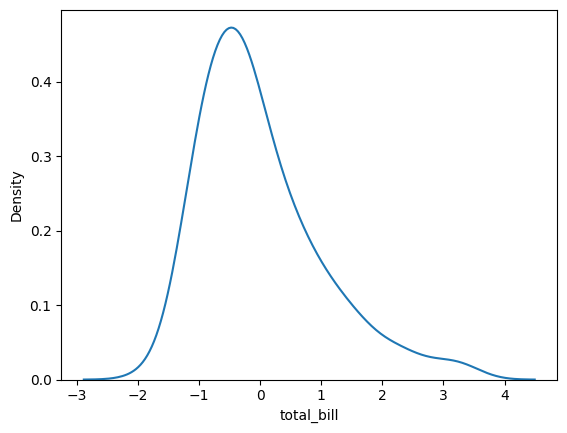

In [ ]:
sns.kdeplot(tips_standard["total_bill"])

# 📌 When to Use These Scaling Methods

## 🟩 Min-Max Scaling
- ✅ When you want all features in a fixed range (0 to 1)  
- ✅ Useful for neural networks and algorithms sensitive to scale  
- ❌ Sensitive to outliers (can compress most data)  

## 🟦 Standardization (Z-score)
- ✅ Best when data has different distributions  
- ✅ Used for SVM, PCA, Logistic Regression, KNN  
- ❌ Not bounded (values can be outside 0–1)  

# 📌 When to NOT Scale
- ❌ Tree-based models (Decision Trees, Random Forest, XGBoost) — they don’t require scaling  
- ❌ Categorical variables — scaling only applies to numeric features
